In [1]:
print("Notebook is working.")

Notebook is working.


In [2]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

print("Torch version:", torch.__version__)
print("Pandas version:", pd.__version__)
print("All imports successful.")

Torch version: 2.10.0+cu128
Pandas version: 3.0.1
All imports successful.


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


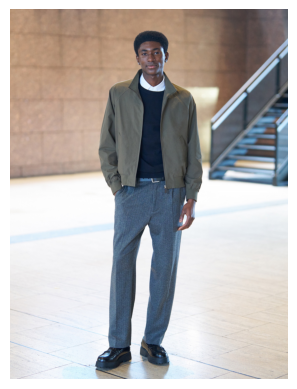

In [4]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "../data/raw/sample.png"
img = Image.open(image_path)

plt.imshow(img)
plt.axis("off")
plt.show()

In [5]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoProcessor

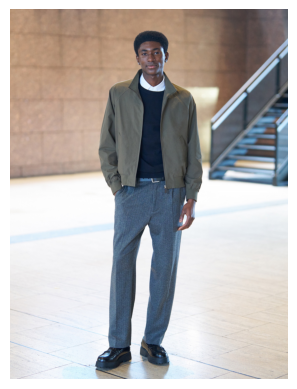

In [6]:
image_path = "../data/raw/sample.png"

image = Image.open(image_path).convert("RGB")
plt.imshow(image)
plt.axis("off")
plt.show()

In [9]:
import torch
from transformers import AutoModelForCausalLM, AutoProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

model_id = "microsoft/Florence-2-base-ft"

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch_dtype,
    trust_remote_code=True
).to(device)

processor = AutoProcessor.from_pretrained(
    model_id,
    trust_remote_code=True
)

print("Model and processor loaded.")
print("Device:", device)
print("Torch dtype:", torch_dtype)

model.safetensors:   0%|          | 0.00/463M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

processing_florence2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-base-ft:
- processing_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/home/aaa79306/.cache/huggingface/modules/transformers_modules/microsoft/Florence-2-base-ft/f6c1a25888ffc1d945ee8a1a77ac833c7303d46e/processing_florence2.py:499: SyntaxWarning: invalid escape sequence '\d'
  """


tokenizer_config.json:   0%|          | 0.00/34.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model and processor loaded.
Device: cuda
Torch dtype: torch.float16


Image size: (1000, 1333)


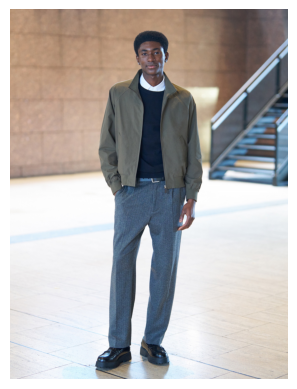

In [10]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "../data/raw/sample.png"
image = Image.open(image_path).convert("RGB")

print("Image size:", image.size)

plt.imshow(image)
plt.axis("off")
plt.show()

In [11]:
prompt = "<MORE_DETAILED_CAPTION>"

inputs = processor(
    text=prompt,
    images=image,
    return_tensors="pt"
).to(device, torch_dtype)

generated_ids = model.generate(
    input_ids=inputs["input_ids"],
    pixel_values=inputs["pixel_values"],
    max_new_tokens=128,
    do_sample=False,
    num_beams=3
)

generated_text = processor.batch_decode(
    generated_ids,
    skip_special_tokens=False
)[0]

print(generated_text)

</s><s>A man is standing on a tiled floor. He is wearing a blue shirt, a brown jacket and blue jeans. He has black shoes on his feet. There is a brown wall behind the man. </s>


In [12]:
parsed_answer = processor.post_process_generation(
    generated_text,
    task=prompt,
    image_size=(image.width, image.height)
)

print(parsed_answer)

{'<MORE_DETAILED_CAPTION>': 'A man is standing on a tiled floor. He is wearing a blue shirt, a brown jacket and blue jeans. He has black shoes on his feet. There is a brown wall behind the man. '}
